In [1]:
# Install a compatible dependency set.
# Pillow must be force-reinstalled because Colab may keep an older/broken wheel loaded.
!apt-get update -qq && apt-get install -y -qq tesseract-ocr
!pip install -q -U --force-reinstall "pillow>=11.0.0" "transformers>=4.45,<4.46"
!pip install -q -U \
    "sentence-transformers>=3.0.1" \
    arxiv langchain langchain-community langchain-huggingface langchain-chroma \
    chromadb pypdf pdfplumber pymupdf pytesseract fastapi uvicorn nest_asyncio \
    langchain-groq \
    einops accelerate
# NOTE: langchain-groq replaces langchain-google-genai (Gemini -> Groq swap).

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [2]:
!pip install -q -U "numpy<2.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 49.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
# IMPORTANT: after running the install cell above, restart the runtime/kernel once.
# In Colab: Runtime > Restart runtime, then continue from this cell.
# The _Ink import error means Python is still using the old Pillow module from memory.
import PIL, transformers
print("Pillow:", PIL.__version__)
print("Transformers:", transformers.__version__)
assert tuple(map(int, PIL.__version__.split(".")[:2])) >= (11, 0), "Restart runtime and rerun from the install cell; Pillow is still too old."


Pillow: 12.3.0
Transformers: 4.45.2


In [ ]:
# Avoid PyPDFLoader here.
# In this Colab runtime, importing langchain_community.document_loaders.PyPDFLoader
# pulls in transformers/torchvision and fails when Pillow is stale in memory.
# The notebook already uses pymupdf (`fitz`), so PDF loading is handled below with fitz.


In [1]:
import os,time,arxiv,requests
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document

from google.colab import userdata
# --- LLM provider: Groq (was Gemini) ---
# In Colab: open the "Secrets" (key icon, left sidebar) and add a secret named
# GROQ_API_KEY with your key from https://console.groq.com/keys
# ChatGroq reads GROQ_API_KEY from the environment, so we export it here.
GROQ_API_KEY = userdata.get('GROQ_API_KEY')
os.environ["GROQ_API_KEY"] = GROQ_API_KEY or ""
assert GROQ_API_KEY, "Add GROQ_API_KEY in Colab Secrets, then rerun this cell."

In [2]:
import PIL
import transformers

print("Pillow:", PIL.__version__)
print("Transformers:", transformers.__version__)

Pillow: 12.3.0
Transformers: 4.45.2


In [3]:
import shutil
shutil.rmtree("./chroma_db", ignore_errors=True)
shutil.rmtree("./papers", ignore_errors=True)
os.remove("./image_descriptions_cache.json") if os.path.exists("./image_descriptions_cache.json") else None
os.makedirs("./papers", exist_ok=True)

In [4]:
PDF_DIR = "./papers"
CHROMA_DIR = "./chroma_db"
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

# Token/runtime controls.
#
# NOTE (Task 3 - chunking): sizes below are now measured in TOKENS (the splitter is
# built from the MiniLM tokenizer in Cell 14), not characters. all-MiniLM-L6-v2 hard-
# truncates at 256 tokens, so 240 keeps whole chunks inside the embedding window with
# headroom. Small chunks also mean fewer tokens per LLM call -> more questions/day
# under Groq's free-tier token budget. Changing this REQUIRES re-running ingestion.
CHUNK_SIZE = 240        # tokens (<= MiniLM's 256 hard cap)
CHUNK_OVERLAP = 40      # tokens
RETRIEVER_K = 3              # final number of chunks sent to the LLM (keep small on free tier)
RETRIEVER_CANDIDATE_K = 12   # wider pool so several papers can be represented
MAX_CONTEXT_CHARS_PER_DOC = 1100   # ~240 tokens; trims any over-long chunk to protect token budget

# --- Retrieval quality controls (Task 2) ---
# Cosine relevance from MiniLM runs low on this data (~0.2-0.5 for good matches),
# so keep the floor small. Retrieval is *guarded*: if the floor removes everything,
# we fall back to the top raw hits so a genuine query never returns empty.
RETRIEVER_MIN_RELEVANCE = 0.15
FIGURE_TABLE_FLOOR = 0.10    # even more lenient for explicit figure/table lookups
MAX_CHUNKS_PER_PAPER = 2     # cap per paper on multi-paper questions so one paper
                            # can't dominate the context window

# --- Table ingestion strategy (v15 REWRITE) ---
# pdfplumber's borderless table extraction SHREDS dense academic tables into fake
# columns ('T5-Sm | all'), so structured grid extraction is abandoned entirely.
# New approach: every 'Table N' caption anchors a RAW TEXT band (the PDF's native
# text layer already contains every cell value in reading order), and ONE cached
# Groq call per table reformats that raw text into a clean markdown grid at
# ingestion time. ~10-15 tables/paper -> trivially inside the Groq free tier,
# one-time cost, cached in image_descriptions_cache.json.
TABLE_REGION_ABOVE = 150     # pts of raw text captured above the caption line
TABLE_REGION_BELOW = 480     # pts captured below (arXiv captions usually sit above the table)
STRUCTURE_TABLES_WITH_LLM = True   # set False to store raw text only (zero LLM calls)
TABLE_LLM_MODEL = "llama-3.1-8b-instant"
TABLE_LLM_MAX_TOKENS = 700
# legacy (kept so old cells don't NameError)

# Real cell values from pdfplumber are now stored INSIDE each table chunk, so
# number-specific table questions can be answered (and grounded) instead of
# relying on MoonDream's vague caption + noisy OCR.
TABLE_GRID_MAX_CHARS = 1800   # cap on the markdown grid stored per table chunk
MAX_CAPTION_DIST = 350        # pts: a 'Table N' caption further than this from the
                              # region is NOT paired (fixes mislabeled table/figure pairs)
# Speed: when a clean grid IS extracted, the expensive MoonDream vision call is
# SKIPPED for that table (grid + caption is strictly better content). Vision+OCR
# only runs as a fallback for tables pdfplumber can't parse.

# Global image RAG policy: no per-paper hardcoding.
# Images are converted into searchable text chunks during ingestion.
IMAGE_RAG_POLICY = {
    "enabled": True,
    "max_images_per_paper": 6,
    "min_width": 180,
    "min_height": 120,
    "render_dpi": 150,
    "use_ocr": True,
    "use_vision_caption": True,
    "caption_margin_above": 300,
    "caption_margin_below": 30,
}

In [15]:
PAPER_IDS = [
    "1706.03762",  # Attention Is All You Need
    "1810.04805",  # BERT
    "2005.11401",  # Retrieval-Augmented Generation (Lewis et al.)
    "1910.13461",  # BART
    "2004.04906",  # Dense Passage Retrieval (DPR)
    "1908.10084",  # Sentence-BERT - the architecture behind all-MiniLM-L6-v2
    "2004.12832",  # ColBERT - late-interaction dense retrieval
    "2007.01282",  # Fusion-in-Decoder - retrieval-augmented generation, FAISS-based
    "1910.10683",  # T5 - text-to-text transfer transformer, useful generation baseline
    "1804.07461",  # GLUE benchmark
    "2010.11929",  # Vision Transformer (ViT)
]

In [16]:
os.makedirs(PDF_DIR, exist_ok=True)

In [17]:
def _download_pdf(pdf_url, filepath, retries=4, connect_to=15, read_to=120):
    """Stream a PDF to disk with a SEPARATE connect vs read timeout and retries.
    The old code passed timeout=30 (applies to BOTH), so a slow arXiv read on a
    big PDF (e.g. T5, 60+ pages) raised ReadTimeout with no retry. Streaming +
    a 120s read timeout + backoff fixes the 'read timeout when adding a paper' bug.
    """
    last = None
    for attempt in range(1, retries + 1):
        try:
            with requests.get(pdf_url, stream=True,
                              timeout=(connect_to, read_to)) as r:
                r.raise_for_status()
                with open(filepath, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1 << 16):
                        if chunk:
                            f.write(chunk)
            if os.path.getsize(filepath) < 1024:
                raise IOError("downloaded file suspiciously small")
            return filepath
        except Exception as e:
            last = e
            wait = min(2 ** attempt, 20)
            print(f"    pdf download failed ({e}); retry {attempt}/{retries} in {wait}s...")
            if os.path.exists(filepath):
                try: os.remove(filepath)
                except OSError: pass
            time.sleep(wait)
    raise RuntimeError(f"could not download {pdf_url} after {retries} attempts: {last}")


def fetch_papers(arxiv_ids, max_retries=5):
    """Download PDFs and collect metadata for each paper.
    Retries with backoff on arXiv 429/503 (rate limiting) instead of
    failing the whole batch outright.
    """
    # Longer delay between arXiv API calls + more built-in retries --
    # the default settings are too aggressive for an 11-paper batch
    # and trip arXiv's rate limiter (429) which can cascade into a 503.
    client = arxiv.Client(page_size=100, delay_seconds=5, num_retries=5)
    search = arxiv.Search(id_list=arxiv_ids)

    for attempt in range(1, max_retries + 1):
        try:
            results = list(client.results(search))
            break
        except Exception as e:
            if attempt == max_retries:
                raise
            wait = 15 * attempt
            print(f"arXiv request failed ({e}); retrying in {wait}s "                  f"(attempt {attempt}/{max_retries})...")
            time.sleep(wait)

    papers = []
    for result in results:
        arxiv_id = result.get_short_id().split("v")[0]
        filename = f"{arxiv_id}.pdf"
        filepath = os.path.join(PDF_DIR, filename)
        if not os.path.exists(filepath):
            pdf_url = next((l.href for l in result.links if l.title == "pdf"), None)
            if pdf_url is None:
                pdf_url = f"https://arxiv.org/pdf/{arxiv_id}.pdf"
            _download_pdf(pdf_url, filepath)
            time.sleep(1)
        papers.append({
            "arxiv_id": arxiv_id,
            "title": result.title,
            "authors": [a.name for a in result.authors[:3]],
            "filepath": filepath,
        })
        print(f"Fetched: {result.title}")
    return papers

In [7]:
import pdfplumber, re

TABLE_CAPTION_RE = re.compile(r'^(Table\s+\d+)\b', re.IGNORECASE)

def _clean_cell(c):
    if c is None:
        return ""
    return " ".join(str(c).split())

def make_table_caption(header, rows):
    """Natural-language description so the embedding has prose to match, not just symbols."""
    cols = [_clean_cell(h) for h in header if _clean_cell(h)]
    if cols:
        return "This table compares: " + ", ".join(cols) + "."
    if rows:
        first = [_clean_cell(c) for c in rows[0] if _clean_cell(c)]
        if first:
            return "This table reports values for: " + ", ".join(first) + "."
    return "This table presents numerical results from the paper."

def _table_is_degenerate(table):
    """Drop mis-detected tables (the source of the '| | | |' garbage)."""
    if not table or len(table) < 2:
        return True
    if max(len(r) for r in table) < 2:
        return True
    nonempty = sum(1 for r in table for c in r if _clean_cell(c))
    return nonempty < 3

def _find_table_labels(page):
    """Lines like 'Table 3: ...' with their vertical position (top-origin)."""
    out = []
    try:
        for line in page.extract_text_lines():
            txt = (line.get("text") or "").strip()
            m = TABLE_CAPTION_RE.match(txt)
            if m:
                out.append((m.group(1).title(), txt, float(line.get("top", 0.0))))
    except Exception:
        pass
    return out

def extract_tables_as_markdown(filepath):
    """Returns {page_number: [(markdown, caption, label, caption_text)]}.

    KEY FIX: each table is paired with the paper's own 'Table N' label and full
    caption line (found via position), so number-specific queries ('what does
    Table 2 report') can match and the LLM sees the label in context.
    """
    page_tables = {}
    with pdfplumber.open(filepath) as pdf:
        for i, page in enumerate(pdf.pages):
            try:
                found = page.find_tables()
            except Exception:
                found = []
            if not found:
                continue
            labels = _find_table_labels(page)   # (label, full_text, top)
            used = set()
            md_tables = []
            for tobj in found:
                try:
                    table = tobj.extract()
                except Exception:
                    continue
                if _table_is_degenerate(table):
                    continue
                header, rows = table[0], table[1:]
                md = "| " + " | ".join(_clean_cell(h) for h in header) + " |\n"
                md += "| " + " | ".join("---" for _ in header) + " |\n"
                for row in rows:
                    md += "| " + " | ".join(_clean_cell(c) for c in row) + " |\n"

                try:
                    ttop = float(tobj.bbox[1])
                except Exception:
                    ttop = None

                # Prefer the nearest 'Table N' caption AT/ABOVE the table (arXiv style);
                # fall back to the nearest unused caption anywhere on the page.
                label, caption_text, best = "", "", None
                for idx, (lab, full, ltop) in enumerate(labels):
                    if idx in used:
                        continue
                    if ttop is None or ltop <= ttop + 6:
                        d = abs((ttop if ttop is not None else 0) - ltop)
                        if best is None or d < best[0]:
                            best = (d, idx, lab, full)
                if best is None:
                    for idx, (lab, full, ltop) in enumerate(labels):
                        if idx in used:
                            continue
                        d = abs((ttop if ttop is not None else 0) - ltop)
                        if best is None or d < best[0]:
                            best = (d, idx, lab, full)
                if best is not None:
                    used.add(best[1]); label, caption_text = best[2], best[3]

                caption = make_table_caption(header, rows)
                md_tables.append((md, caption, label, caption_text))
            if md_tables:
                page_tables[i + 1] = md_tables
    return page_tables

In [8]:
import fitz, hashlib, io, torch
from PIL import Image
from transformers import AutoModelForCausalLM, AutoTokenizer

try:
    import pytesseract
except Exception:
    pytesseract = None

CACHE_PATH = "./image_descriptions_cache.json"

_moondream_model = None
_moondream_tokenizer = None

def get_moondream():
    global _moondream_model, _moondream_tokenizer
    if _moondream_model is None:
        _moondream_model = AutoModelForCausalLM.from_pretrained(
            "vikhyatk/moondream2", trust_remote_code=True
        ).to("cuda" if torch.cuda.is_available() else "cpu")
        _moondream_tokenizer = AutoTokenizer.from_pretrained("vikhyatk/moondream2")
    return _moondream_model, _moondream_tokenizer

def load_cache():
    if os.path.exists(CACHE_PATH):
        try:
            with open(CACHE_PATH) as f:
                content = f.read().strip()
                if not content:
                    return {}
                return json.loads(content)
        except json.JSONDecodeError:
            print(f"Warning: {CACHE_PATH} was corrupted/unreadable, starting fresh.")
            return {}
    return {}

def save_cache(cache):
    with open(CACHE_PATH, "w") as f:
        json.dump(cache, f, indent=2)

def describe_image_local(image_bytes):
    """Generate a compact figure/chart/diagram caption using MoonDream locally."""
    model, tokenizer = get_moondream()
    img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    enc = model.encode_image(img)
    return model.answer_question(
        enc,
        "This is a figure, chart, diagram, or screenshot from a research paper. "
        "Describe the important visual information in 2-4 concise sentences. "
        "Include chart axes, legends, architecture blocks, arrows, trends, or comparisons if visible.",
        tokenizer,
    )

def ocr_image_local(image_bytes):
    """Extract embedded text from a figure image using local Tesseract OCR."""
    if pytesseract is None:
        return ""
    try:
        img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
        text = pytesseract.image_to_string(img, config="--psm 6")
        return " ".join(text.split())
    except Exception as e:
        print(f"    OCR failed: {e}")
        return ""

import re

def find_figure_regions(page, margin_above=None, margin_below=None):
    """Find figure regions by locating Figure/Fig captions and cropping above them."""
    margin_above = margin_above or IMAGE_RAG_POLICY["caption_margin_above"]
    margin_below = margin_below or IMAGE_RAG_POLICY["caption_margin_below"]
    regions = []
    caption_pattern = re.compile(r"^(Figure|Fig\.)\s*\d+", re.IGNORECASE)

    for block in page.get_text("dict").get("blocks", []):
        if "lines" not in block:
            continue
        block_text = "".join(
            span["text"] for line in block["lines"] for span in line["spans"]
        ).strip()
        if caption_pattern.match(block_text):
            caption_bbox = fitz.Rect(block["bbox"])
            fig_rect = fitz.Rect(
                0,
                max(0, caption_bbox.y0 - margin_above),
                page.rect.width,
                min(page.rect.height, caption_bbox.y0 + margin_below),
            )
            regions.append({
                "rect": fig_rect,
                "caption_text": block_text,
            })
    return regions

def build_figure_rag_text(title, arxiv_id, page_num, caption_text, ocr_text, vision_caption):
    parts = [
        f"Figure/Image from research paper: {title}",
        f"arXiv ID: {arxiv_id}",
        f"Page: {page_num}",
    ]
    if caption_text:
        parts.append(f"PDF figure caption: {caption_text}")
    if ocr_text:
        parts.append(f"Text detected inside image/chart/diagram: {ocr_text}")
    if vision_caption:
        parts.append(f"Visual interpretation: {vision_caption}")
    return "\n".join(parts)

def _render_region_png(fitz_page, bbox, dpi=150):
    """Render a sub-rectangle (x0, top, x1, bottom, in PDF points) of a page to PNG bytes.
    pdfplumber and PyMuPDF share the same top-left point coordinate space, so a
    pdfplumber table.bbox maps directly onto a fitz.Rect."""
    rect = fitz.Rect(*bbox)
    zoom = dpi / 72.0
    pix = fitz_page.get_pixmap(matrix=fitz.Matrix(zoom, zoom), clip=rect)
    return pix.tobytes("png")


def _bbox_iou(a, b):
    ax0, ay0, ax1, ay1 = a; bx0, by0, bx1, by1 = b
    ix0, iy0 = max(ax0, bx0), max(ay0, by0)
    ix1, iy1 = min(ax1, bx1), min(ay1, by1)
    iw, ih = max(0, ix1 - ix0), max(0, iy1 - iy0)
    inter = iw * ih
    if inter <= 0:
        return 0.0
    area_a = max(0.0, ax1 - ax0) * max(0.0, ay1 - ay0)
    area_b = max(0.0, bx1 - bx0) * max(0.0, by1 - by0)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


TABLE_CAPTION_FITZ_RE = re.compile(r"^(Table)\s+(\d+)\s*[:.]", re.IGNORECASE)

def _find_table_captions_fitz(page):
    """'Table N: ...' caption blocks with their bbox, via fitz (no pdfplumber)."""
    out = []
    for block in page.get_text("dict").get("blocks", []):
        if "lines" not in block:
            continue
        text = " ".join(
            span["text"] for line in block["lines"] for span in line["spans"]
        ).strip()
        m = TABLE_CAPTION_FITZ_RE.match(text)
        if m:
            out.append({
                "label": f"Table {m.group(2)}",
                "caption_text": " ".join(text.split())[:400],
                "bbox": fitz.Rect(block["bbox"]),
            })
    out.sort(key=lambda c: c["bbox"].y0)
    return out


_table_llm = None
def _get_table_llm():
    """Small Groq model used ONCE per table at ingestion (cached). Lazy so the
    ingestion cells don't depend on the serving cells having run."""
    global _table_llm
    if _table_llm is None:
        from langchain_groq import ChatGroq
        _table_llm = ChatGroq(model=TABLE_LLM_MODEL, temperature=0.0,
                              max_tokens=TABLE_LLM_MAX_TOKENS)
    return _table_llm

_TABLE_STRUCTURE_PROMPT = (
    "Below is raw text extracted from a table region of a research paper PDF. "
    "The values are in reading order but the column structure was lost.\n"
    "Reconstruct the table as a compact markdown table (| col | col |). Keep every "
    "numeric value EXACTLY as written -- do not round, invent, or omit numbers. "
    "If the structure cannot be confidently reconstructed, instead list each row as "
    "'row-label: values' lines. Output ONLY the table/rows, no commentary.\n\n"
    "Caption: {caption}\n\nRaw text:\n{raw}"
)

_TABLE_LLM_DISABLED = False   # set True after an auth error to stop retrying

def _structure_table_with_llm(caption_text, raw_text):
    global _TABLE_LLM_DISABLED
    if _TABLE_LLM_DISABLED:
        return ""
    try:
        resp = _get_table_llm().invoke(
            _TABLE_STRUCTURE_PROMPT.format(caption=caption_text, raw=raw_text[:3500]))
        out = (resp.content or "").strip()
        # sanity: the LLM must not invent numbers -- keep only if most of its
        # numeric tokens actually appear in the raw text.
        raw_ns = re.sub(r"\s+", "", raw_text)
        nums = re.findall(r"\d+(?:\.\d+)?", out)
        if nums:
            supported = sum(1 for n in nums if n in raw_ns)
            if supported / len(nums) < 0.85:
                return ""
        return out
    except Exception as e:
        msg = str(e)
        if "401" in msg or "invalid_api_key" in msg or "Invalid API Key" in msg:
            _TABLE_LLM_DISABLED = True
            print("    !! GROQ AUTH FAILED (401). Disabling LLM table structuring for "
                  "this run and falling back to RAW TABLE TEXT. Re-run cell 4 to reload "
                  "GROQ_API_KEY (or make a new key), then re-ingest -- cached tables are "
                  "kept, only failed ones get re-structured.")
        else:
            print(f"    table LLM structuring skipped: {e}")
        return ""


def describe_table_regions(filepath, paper):
    """v15 REWRITE: caption-anchored table ingestion. One chunk per 'Table N'
    caption, guaranteed.

    Why: pdfplumber's find_tables() shreds borderless academic tables into fake
    columns ('T5-Sm | all'), and vision captions carry no cell values. But the
    PDF's NATIVE text layer already contains every number in reading order. So:
      1. locate each 'Table N' caption via fitz,
      2. capture the raw text band around it (bounded by neighbouring captions),
      3. (optional, cached) one Groq call reformats the raw text into a markdown
         grid -- with a groundedness sanity check so it can't invent numbers.
    No pdfplumber, no vision, no OCR on the table path -> much faster ingestion,
    and every stored value is real PDF text, so answers pass the grounding check.
    """
    docs = []
    cache = load_cache()
    fitz_doc = fitz.open(filepath)
    try:
        for i, page in enumerate(fitz_doc):
            captions = _find_table_captions_fitz(page)
            if not captions:
                continue
            for ci, cap in enumerate(captions):
                y0 = cap["bbox"].y0
                # band above/below the caption, bounded by neighbouring captions
                top = max(0, y0 - TABLE_REGION_ABOVE)
                if ci > 0:
                    top = max(top, captions[ci - 1]["bbox"].y1 + 4)
                bottom = min(page.rect.height, cap["bbox"].y1 + TABLE_REGION_BELOW)
                if ci + 1 < len(captions):
                    bottom = min(bottom, captions[ci + 1]["bbox"].y0 - 4)
                clip = fitz.Rect(0, top, page.rect.width, bottom)
                raw = " ".join((page.get_text("text", clip=clip) or "").split())
                if len(raw) < 40:
                    continue

                key = f"{paper['arxiv_id']}_tblv15_p{i+1}_{cap['label'].replace(' ', '')}"
                structured = ""
                if STRUCTURE_TABLES_WITH_LLM:
                    if key in cache and "structured" in cache[key]:
                        structured = cache[key]["structured"]
                    else:
                        structured = _structure_table_with_llm(cap["caption_text"], raw)
                        cache[key] = {"structured": structured}
                        time.sleep(0.35)   # gentle on the free-tier rate limit

                body = ("Table values (reconstructed):\n" + structured) if structured \
                       else ("Table text (raw): " + raw[:TABLE_GRID_MAX_CHARS])
                content = (
                    f"{cap['label']} from '{paper['title']}' (page {i+1}).\n"
                    f"{cap['caption_text']}\n{body}"
                ).strip()
                docs.append(Document(
                    page_content=content,
                    metadata={
                        "arxiv_id": paper["arxiv_id"],
                        "title": paper["title"],
                        "authors": paper["authors"],
                        "page": i + 1,
                        "table_label": cap["label"],
                        "source": f"{paper['title'][:50]} (arXiv:{paper['arxiv_id']}, p.{i+1}, {cap['label']})",
                        "content_type": "table",
                        "has_structured": bool(structured),
                    },
                ))
    finally:
        save_cache(cache)
        fitz_doc.close()
    print(f"    tables: {len(docs)} caption-anchored chunk(s)")
    return docs


def extract_and_describe_figures(filepath, paper):
    """Convert selected chart/diagram/image regions into searchable RAG text chunks.

    This is global-policy driven: every new paper uses the same policy. OCR is cheap;
    vision captioning is cached and bounded by max_images_per_paper.
    """
    if not IMAGE_RAG_POLICY.get("enabled", True):
        return []

    doc = fitz.open(filepath)
    figure_docs = []
    cache = load_cache()
    seen_hashes = set()
    n_processed = 0

    max_images = IMAGE_RAG_POLICY["max_images_per_paper"]
    min_width = IMAGE_RAG_POLICY["min_width"]
    min_height = IMAGE_RAG_POLICY["min_height"]
    render_dpi = IMAGE_RAG_POLICY["render_dpi"]
    use_ocr = IMAGE_RAG_POLICY["use_ocr"]
    use_vision = IMAGE_RAG_POLICY["use_vision_caption"]

    for page_num, page in enumerate(doc, start=1):
        if n_processed >= max_images:
            break

        regions = find_figure_regions(page)
        for region_index, region_info in enumerate(regions):
            if n_processed >= max_images:
                break

            rect = region_info["rect"]
            caption_text = region_info.get("caption_text", "")
            if rect.height < 50 or rect.width < 50:
                continue

            pix = page.get_pixmap(clip=rect, dpi=render_dpi)
            if pix.width < min_width or pix.height < min_height:
                continue

            image_bytes = pix.tobytes("png")
            img_hash = hashlib.md5(image_bytes).hexdigest()
            if img_hash in seen_hashes:
                continue
            seen_hashes.add(img_hash)

            arxiv_id = paper["arxiv_id"]
            title = paper["title"]
            img_path = os.path.join(PDF_DIR, f"{arxiv_id}_p{page_num}_fig{region_index}.png")
            with open(img_path, "wb") as f:
                f.write(image_bytes)

            cache_key = f"{arxiv_id}_p{page_num}_fig{region_index}_{img_hash}"
            cached = cache.get(cache_key, {})

            if use_ocr and "ocr_text" in cached:
                ocr_text = cached["ocr_text"]
            elif use_ocr:
                ocr_text = ocr_image_local(image_bytes)
            else:
                ocr_text = ""

            if use_vision and "vision_caption" in cached:
                vision_caption = cached["vision_caption"]
                print(f"    (cached image RAG) p{page_num} fig{region_index}")
            elif use_vision:
                try:
                    vision_caption = describe_image_local(image_bytes)
                    print(f"    (new image RAG) p{page_num} fig{region_index}")
                except Exception as e:
                    print(f"    Vision caption failed p{page_num} fig{region_index}: {e}")
                    vision_caption = ""
            else:
                vision_caption = ""

            cache[cache_key] = {
                "ocr_text": ocr_text,
                "vision_caption": vision_caption,
                "caption_text": caption_text,
                "image_path": img_path,
            }
            save_cache(cache)

            page_content = build_figure_rag_text(
                title=title,
                arxiv_id=arxiv_id,
                page_num=page_num,
                caption_text=caption_text,
                ocr_text=ocr_text,
                vision_caption=vision_caption,
            )

            # Only add useful image chunks. Caption-only placeholders are allowed,
            # but empty OCR + empty vision + empty caption is noise.
            if not (caption_text or ocr_text or vision_caption):
                continue

            figure_docs.append(Document(
                page_content=page_content,
                metadata={
                    "arxiv_id": arxiv_id,
                    "title": title,
                    "authors": paper["authors"],
                    "page": page_num,
                    "figure_label": (
                        (lambda m: f"Figure {m.group(1)}" if m else "")(
                            re.match(r"(?:Figure|Fig\.?)\s*(\d+)", caption_text or "", re.IGNORECASE))
                    ),
                    "source": f"{title[:50]} (arXiv:{arxiv_id}, p.{page_num}, figure/image)",
                    "content_type": "figure",
                    "image_path": img_path,
                    "has_ocr_text": bool(ocr_text),
                    "has_vision_caption": bool(vision_caption),
                },
            ))
            n_processed += 1

    return figure_docs


In [9]:
if os.path.exists("./image_descriptions_cache.json"):
    os.remove("./image_descriptions_cache.json")
    print("Removed corrupted cache file.")
else:
    print("No cache file found — nothing to remove.")

No cache file found — nothing to remove.


In [10]:
from transformers import AutoTokenizer

_hf_tokenizer = None
def _get_chunk_tokenizer():
    """MiniLM's own tokenizer, loaded once. Local + free. Lets us size chunks by
    TOKENS so they always fit the 256-token embedding window."""
    global _hf_tokenizer
    if _hf_tokenizer is None:
        _hf_tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL)
    return _hf_tokenizer


def load_pdf_pages_with_fitz(filepath):
    """Load one Document per PDF page without importing PyPDFLoader/langchain-community."""
    pages = []
    with fitz.open(filepath) as pdf:
        total_pages = pdf.page_count
        for page_index, page in enumerate(pdf):
            text = page.get_text("text") or ""
            pages.append(Document(
                page_content=text,
                metadata={
                    "source_file": filepath,
                    "page": page_index,
                    "total_pages": total_pages,
                },
            ))
    return pages


def load_and_chunk(papers):
    # Task 3: structure-first, TOKEN-sized chunking (fits MiniLM's 256-token window,
    # keeps per-call tokens low for the free tier).
    splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        _get_chunk_tokenizer(),
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP,
        separators=["\n\n", "\n", ". ", "? ", "! ", "; ", ", ", " ", ""],
        keep_separator=True,
    )
    all_chunks = []
    for paper in papers:
        pages = load_pdf_pages_with_fitz(paper["filepath"])
        chunks = splitter.split_documents(pages)
        for chunk in chunks:
            page_number = chunk.metadata.get("page", 0) + 1
            chunk.metadata.update({
                "arxiv_id": paper["arxiv_id"],
                "title": paper["title"],
                "authors": paper["authors"],
                "page": page_number,
                "source": f"{paper['title'][:50]} (arXiv:{paper['arxiv_id']}, p.{page_number})",
                "content_type": "text",
            })
        all_chunks.extend(chunks)

        # Tables via the VISION path (render region -> MoonDream + OCR), not pdfplumber's
        # markdown grid, which mangles dense academic tables. Keeps the 'Table N' label.
        table_docs = describe_table_regions(paper["filepath"], paper)
        all_chunks.extend(table_docs)
        table_count = len(table_docs)

        image_docs = extract_and_describe_figures(paper["filepath"], paper)
        all_chunks.extend(image_docs)

        print(
            f"  {paper['title'][:50]}... -> "
            f"{len(chunks)} text + {table_count} tables + {len(image_docs)} image-derived chunks"
        )
    return all_chunks

In [11]:
def _dedupe_chunks(chunks):
    """Drop exact-duplicate chunks (same paper+page+type+opening text) before they
    ever reach the embedder. Cheap insurance against double-ingestion."""
    seen, out = set(), []
    for d in chunks:
        key = (d.metadata.get("arxiv_id"), d.metadata.get("page"),
               d.metadata.get("content_type", "text"), d.page_content[:120])
        if key not in seen:
            seen.add(key)
            out.append(d)
    dropped = len(chunks) - len(out)
    if dropped:
        print(f"  _dedupe_chunks: dropped {dropped} duplicate chunk(s) before embedding")
    return out


def build_vectorstore(chunks, reset=False):
    """FIX (was silently duplicating on re-run): reset=True used to call
    Chroma.from_documents() against an EXISTING persist_directory, which does not
    clear old data -- it just adds on top. If a prior run crashed partway through
    (e.g. the 'readonly database' error) any chunks it had already written stayed,
    and the next successful run added a full second copy on top of them.
    Now reset=True EXPLICITLY drops the collection (and the on-disk folder as a
    belt-and-suspenders fallback) before writing, so a reset is always a true wipe."""
    embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)
    chunks = _dedupe_chunks(chunks)

    if reset:
        try:
            import chromadb
            chromadb.api.client.SharedSystemClient.clear_system_cache()
        except Exception:
            pass
        shutil.rmtree(CHROMA_DIR, ignore_errors=True)

    if reset or not os.path.exists(CHROMA_DIR):
        vectorstore = Chroma.from_documents(
            documents=chunks,
            embedding=embeddings,
            persist_directory=CHROMA_DIR,
            collection_name="arxiv_papers",
            collection_metadata={"hnsw:space": "cosine"},
        )
    else:
        vectorstore = Chroma(
            persist_directory=CHROMA_DIR,
            embedding_function=embeddings,
            collection_name="arxiv_papers",
            collection_metadata={"hnsw:space": "cosine"},
        )
        vectorstore.add_documents(chunks)
    return vectorstore

In [12]:
def sanity_check(vectorstore):
    query = "What is self-attention?"
    results = vectorstore.similarity_search(query, k=3)
    print(f"\nTest query: '{query}'")
    for i, doc in enumerate(results, 1):
        print(f"\n  Result {i}")
        print(f"  Source: {doc.metadata.get('source', 'MISSING - check metadata')}")
        print(f"  Preview: {doc.page_content[:200]}...")

In [13]:
import json

def save_papers_index(papers):
    index = [{"arxiv_id": p["arxiv_id"], "title": p["title"], "authors": p["authors"]} for p in papers]
    with open("./papers_index.json", "w") as f:
        json.dump(index, f, indent=2)
    print(f"Saved index with {len(index)} papers")

In [18]:
if __name__ == "__main__":

    def _preflight_groq_key():
    """Fail LOUD and EARLY if the Groq key is missing/dead, instead of discovering
    it table-by-table halfway through ingestion."""
    import os
    k = os.environ.get("GROQ_API_KEY", "")
    if not k:
        print("!! GROQ_API_KEY not set. Re-run cell 4 (loads it from Colab secrets) "
              "before ingesting. Ingestion will still run but tables store RAW text only.")
        return False
    try:
        from langchain_groq import ChatGroq
        ChatGroq(model=TABLE_LLM_MODEL, temperature=0.0, max_tokens=5).invoke("ping")
        print(f"Groq key OK (prefix {k[:4]}..., len {len(k)}).")
        return True
    except Exception as e:
        print(f"!! Groq key present but rejected: {e}\n"
              "   Re-run cell 4 or generate a new key at console.groq.com. "
              "Tables will fall back to raw text this run.")
        return False

_preflight_groq_key()

print("Step 1/4: Fetching papers from arXiv...")
    papers = fetch_papers(PAPER_IDS)

    print("\nStep 2/4: Loading and chunking PDFs (text + tables + OCR/vision image RAG chunks)...")
    chunks = load_and_chunk(papers)
    print(f"\nTotal chunks created: {len(chunks)}")

    print("\nStep 3/4: Embedding and storing in ChromaDB...")
    vectorstore = build_vectorstore(chunks, reset=True)
    print(f"Stored at: {CHROMA_DIR}")

    print("\nStep 4/4: Sanity check...")
    sanity_check(vectorstore)

    save_papers_index(papers)


Step 1/4: Fetching papers from arXiv...
Fetched: Attention Is All You Need
Fetched: BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding
Fetched: GLUE: A Multi-Task Benchmark and Analysis Platform for Natural Language Understanding
Fetched: ColBERT: Efficient and Effective Passage Search via Contextualized Late Interaction over BERT
Fetched: Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks
Fetched: Dense Passage Retrieval for Open-Domain Question Answering
Fetched: Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer
Fetched: BART: Denoising Sequence-to-Sequence Pre-training for Natural Language Generation, Translation, and Comprehension
Fetched: Leveraging Passage Retrieval with Generative Models for Open Domain Question Answering
Fetched: Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks
Fetched: An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale

Step 2/4: Loading and chunki

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  _dedupe_chunks: dropped 15 duplicate chunk(s) before embedding
Stored at: ./chroma_db

Step 4/4: Sanity check...

Test query: 'What is self-attention?'

  Result 1
  Source: Exploring the Limits of Transfer Learning with a U (arXiv:1910.10683, p.16)
  Preview: Raffel, Shazeer, Roberts, Lee, Narang, Matena, Zhou, Li and Liu
x1
x2
x3
x4
x5
y5
y4
y3
y2
y1
x1
x2
x3
x4
x5
y5
y4
y3
y2
y1
x1
x2
x3
x4
x5
y5
y4
y3
y2
y1
Figure 3: Matrices representing different atte...

  Result 2
  Source: Attention Is All You Need (arXiv:1706.03762, p.13, figure/image)
  Preview: Figure/Image from research paper: Attention Is All You Need
arXiv ID: 1706.03762
Page: 13
PDF figure caption: Figure 3: An example of the attention mechanism following long-distance dependencies in th...

  Result 3
  Source: Attention Is All You Need (arXiv:1706.03762, p.5)
  Preview: is similar to that of single-head attention with full dimensionality.
3.2.3
Applications of Attention in our Model
The Transformer uses multi-head a

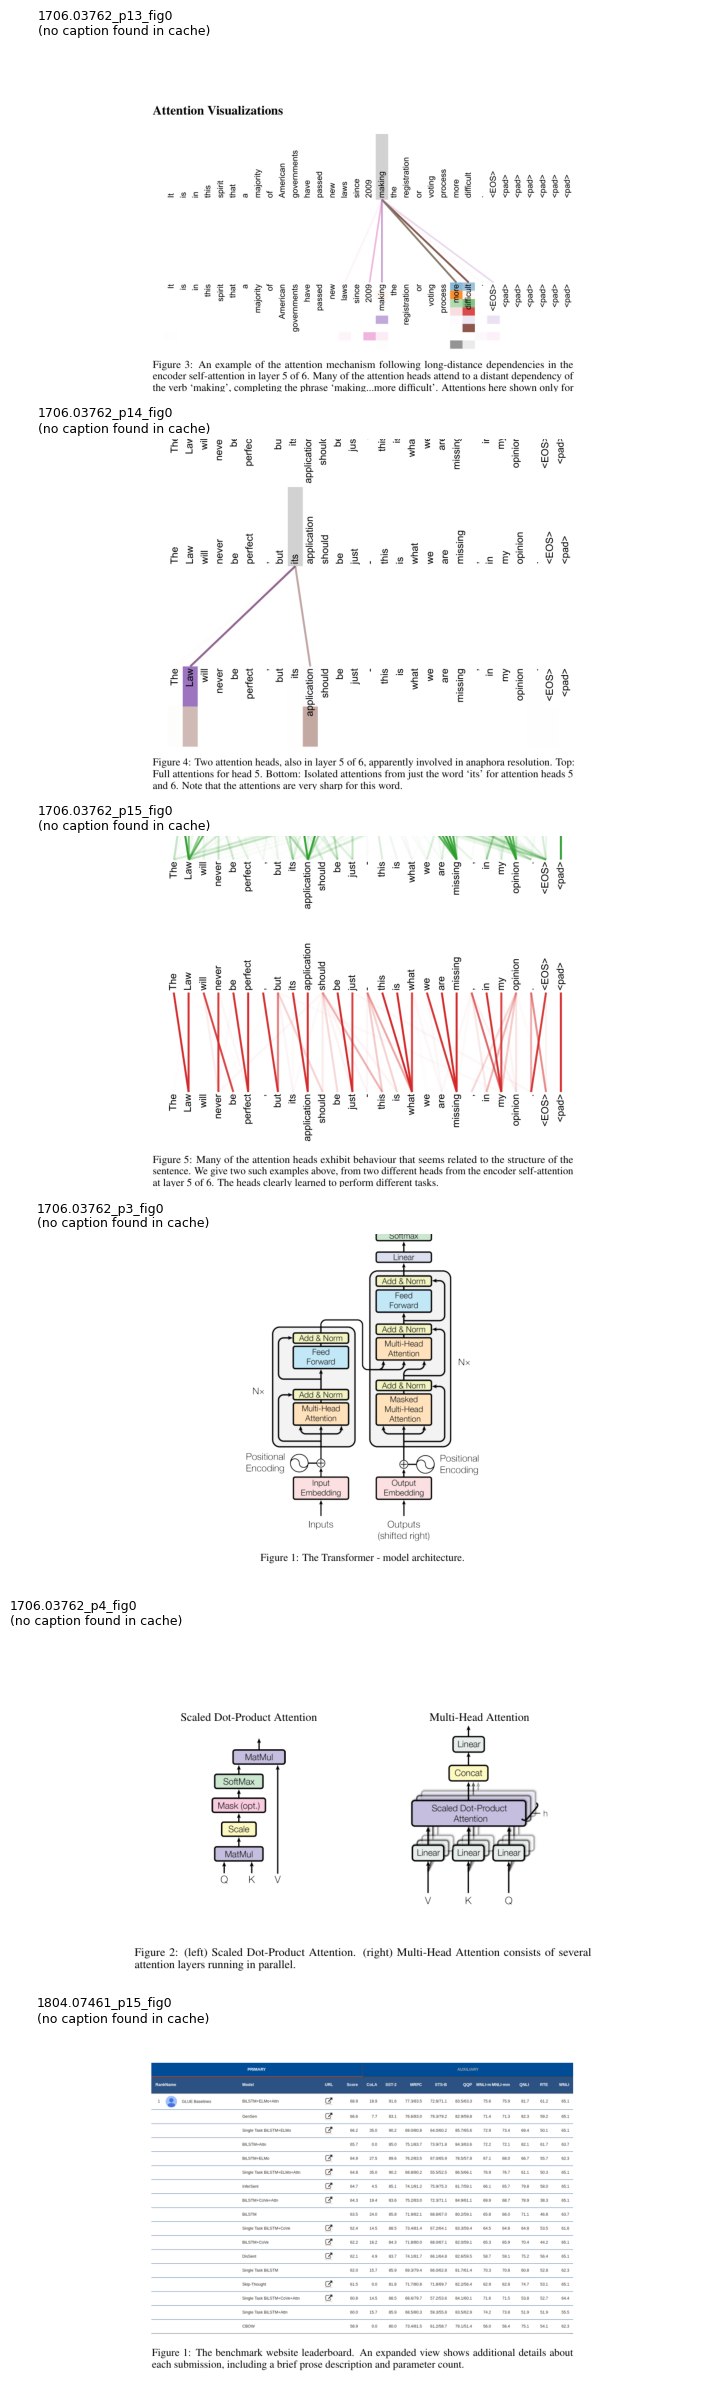

In [19]:
import glob
import matplotlib.pyplot as plt
from PIL import Image

def preview_extracted_figures(n=6):
    """Display the first n extracted figure crops alongside their MoonDream captions."""
    image_paths = sorted(glob.glob(os.path.join(PDF_DIR, "*_fig*.png")))[:n]

    if not image_paths:
        print("No figure images found — check PDF_DIR and that extract_and_describe_figures ran.")
        return

    cache = load_cache()

    fig, axes = plt.subplots(len(image_paths), 1, figsize=(8, 4 * len(image_paths)))
    if len(image_paths) == 1:
        axes = [axes]

    for ax, path in zip(axes, image_paths):
        img = Image.open(path)
        ax.imshow(img)
        ax.axis("off")

        # derive cache key from filename to look up the caption
        fname = os.path.basename(path).replace(".png", "")
        caption = cache.get(fname, "(no caption found in cache)")
        ax.set_title(f"{fname}\n{caption}", fontsize=9, wrap=True, loc="left")

    plt.tight_layout()
    plt.show()

preview_extracted_figures(n=6)

In [20]:
import os
import json
import threading
import nest_asyncio
import uvicorn
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

nest_asyncio.apply()

In [21]:
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)

vectorstore = Chroma(
    persist_directory=CHROMA_DIR,
    embedding_function=embeddings,
    collection_name="arxiv_papers",
    collection_metadata={"hnsw:space": "cosine"},
)

# --- Groq LLM (was ChatGoogleGenerativeAI / gemini-2.5-flash-lite) ---
# FREE-TIER CHOICE: llama-3.1-8b-instant.
#   Free plan (per Groq docs, mid-2026):
#     llama-3.1-8b-instant  -> 30 RPM, 14,400 RPD, ~6K TPM,  500K tokens/DAY
#     llama-3.3-70b-versatile-> 30 RPM,  1,000 RPD, 12K TPM,  100K tokens/DAY
#   Each RAG answer costs ~2-4K tokens, so 8b's 500K/day budget = ~5x more questions
#   per day than 70b before you hit the wall. 8b is plenty for GROUNDED QA (the model
#   only has to synthesise retrieved chunks, not reason from scratch).
#   For harder comparative questions, switch this one line to "llama-3.3-70b-versatile"
#   (better quality, but you'll run out of daily tokens ~5x faster on the free tier).
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.3,
    max_tokens=768,   # concise research answers; caps output tokens to protect free-tier budget
)
print(f"Vectorstore loaded: {vectorstore._collection.count()} chunks")
print(f"LLM: {llm.model_name}")

Vectorstore loaded: 1114 chunks
LLM: llama-3.1-8b-instant


In [22]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.output_parsers import StrOutputParser
from collections import OrderedDict, defaultdict, Counter
import re
import json as _json

# ------------------------------------------------------------------ Task 2: retrieval
# Retrieval now uses similarity_search_with_relevance_scores so we can:
#   (a) apply a lenient relevance FLOOR to cut obvious noise (guarded: never returns
#       empty on a real query),
#   (b) DIVERSIFY across papers for multi-paper / comparative questions, and
#   (c) run a dedicated content_type-filtered pass for explicit figure/table lookups
#       so those chunks are reliably surfaced even if the general pool missed them.
# Default behaviour still PRIORITISES plain-text chunks; figures/tables only lead when
# the question asks for them or when text alone can't fill the K slots.
# The vectorstore is on cosine distance (see build_vectorstore) so relevance scores
# are bounded and comparable. All of this is plain Python -- no extra LLM calls.

contextualize_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You rewrite the user's latest question so it stands alone without the chat "
     "history. Rules:\n"
     "1. If the latest question is ALREADY self-contained, return it EXACTLY as written.\n"
     "2. Only resolve back-references (it, this, that, the same paper) into the "
     "specific entity they point to in the history.\n"
     "3. NEVER add any topic, entity, name, or sub-question that the latest question "
     "did not itself ask about, even if it appears in the history.\n"
     "Return ONLY the rewritten question and nothing else."),
    MessagesPlaceholder("chat_history"),
    ("human", "{input}"),
])

qa_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a research paper assistant. Answer using the Context below, and base "
     "every factual claim on it -- do not add specific numbers, results, or facts that "
     "are not in the Context. The Context is drawn from several indexed arXiv papers and "
     "may include text, tables, or figure descriptions; it is normal for it to contain "
     "chunks from more than one paper, so use whichever chunks are relevant to the "
     "question and ignore the rest. "
     "If a Context chunk is labelled with the exact Table/Figure the question asks "
     "about, that chunk IS the answer: describe what it reports using its caption and "
     "values -- do NOT use the fallback reply in that case. "
     "If the Context contains a table grid, report only the values relevant to the "
     "question in prose or a SMALL excerpt -- never reproduce a large table verbatim. "
     "Be concise (4-8 sentences unless asked for detail) and cite the paper and page you "
     "used. Only if NONE of the Context is relevant to the question, reply exactly: "
     "\"I don't have information about this in the currently indexed documents.\"\n\n"
     "Context:\n{context}"
    ),
    MessagesPlaceholder("chat_history"),
    ("human", "{input}"),
])

# Keywords that suggest the user actually wants a table/figure, not just prose.
FIGURE_TABLE_HINTS = (
    "figure", "fig.", "table", "chart", "diagram", "graph", "plot", "image",
    "illustration", "architecture diagram", "shown in",
)

# Cues that a question spans/compares multiple papers.
MULTI_PAPER_HINTS = (
    "compare", "comparison", "versus", " vs ", "vs.", "difference between", "differ",
    "contrast", "both", "across", "each paper", "these papers", "all papers",
    "which paper", "trade-off", "tradeoff", "relative to", "compared to",
)


# Vague 'summarize / overview' queries don't semantically match any one chunk well
# (the word 'summarize' isn't in the abstract), so retrieval used to pull junk.
# Fix: detect summary intent and pull the target paper's EARLIEST pages directly
# (abstract + intro live there) instead of trusting pure similarity.
SUMMARY_HINTS = ("summarize", "summarise", "summary", "overview", "tl;dr", "tldr",
                 "what is this paper about", "what is the paper about", "about the paper",
                 "main contribution", "main idea", "key idea", "key contributions",
                 "in a nutshell", "briefly explain the paper", "abstract")

def wants_summary(question):
    q = (question or "").lower()
    return any(h in q for h in SUMMARY_HINTS)


def retrieve_early_pages(arxiv_id, max_docs=RETRIEVER_K):
    """Fetch the target paper's earliest text chunks straight from Chroma.
    Deterministic -- no similarity involved, so 'summarize X' always sees the
    abstract/intro. v14: single get() + python sort (avoids int-equality quirks
    in Chroma where-filters), then keep the lowest-page chunks."""
    docs = []
    try:
        got = vectorstore._collection.get(
            where={"$and": [{"arxiv_id": arxiv_id}, {"content_type": "text"}]},
            include=["documents", "metadatas"],
        )
        pairs = list(zip(got.get("documents") or [], got.get("metadatas") or []))
        pairs.sort(key=lambda p: (p[1] or {}).get("page", 10**6))
        for txt, md in pairs[:max_docs]:
            docs.append(Document(page_content=txt, metadata=md or {}))
    except Exception as e:
        print(f"  retrieve_early_pages failed: {e}")
    return docs


def wants_figure_or_table(question):
    q = question.lower()
    return any(hint in q for hint in FIGURE_TABLE_HINTS)


def wants_multi_paper(question, scored_docs=None):
    """Multi-paper intent ONLY on an explicit comparative cue. The old
    'top candidates span >=3 papers' auto-trigger fired on ordinary single-topic
    follow-ups (e.g. 'explain it more elaborately') and scattered the context
    across unrelated papers -- that is what produced the incoherent 3-paper answer.
    Removed."""
    q = f" {question.lower()} "
    return any(hint in q for hint in MULTI_PAPER_HINTS)


def _dedupe(docs):
    seen, out = set(), []
    for d in docs:
        key = (d.metadata.get("arxiv_id"), d.metadata.get("page"),
               d.metadata.get("content_type", "text"), d.page_content[:80])
        if key not in seen:
            seen.add(key)
            out.append(d)
    return out


def retrieve_scored(query, k=RETRIEVER_CANDIDATE_K,
                    min_relevance=RETRIEVER_MIN_RELEVANCE, content_types=None):
    """Return [(doc, score)] sorted by relevance, above a lenient floor.

    Guarded: if the floor removes everything, fall back to the top raw hits so a
    genuine query never returns empty. `content_types` applies a Chroma metadata
    filter (used for the dedicated figure/table pass).
    """
    kwargs = {}
    if content_types:
        kwargs["filter"] = {"content_type": {"$in": list(content_types)}}
    try:
        scored = vectorstore.similarity_search_with_relevance_scores(query, k=k, **kwargs)
    except TypeError:
        # Older langchain-chroma used `where` instead of `filter`.
        if content_types:
            kwargs = {"where": {"content_type": {"$in": list(content_types)}}}
        scored = vectorstore.similarity_search_with_relevance_scores(query, k=k, **kwargs)
    scored.sort(key=lambda x: (x[1] is not None, x[1] or 0.0), reverse=True)
    kept = [(d, s) for d, s in scored if (s is None or s >= min_relevance)]
    if not kept and scored:
        kept = scored[:RETRIEVER_K]  # never starve a real query
    return kept


def diversify_by_paper(scored_docs, final_k=RETRIEVER_K,
                       max_per_paper=MAX_CHUNKS_PER_PAPER):
    """Round-robin across papers (best score first within each) so multi-paper
    questions get coverage instead of K chunks from a single paper."""
    buckets = OrderedDict()
    for d, _ in scored_docs:  # already sorted best-first
        buckets.setdefault(d.metadata.get("arxiv_id", "?"), []).append(d)
    selected, counts = [], defaultdict(int)
    while len(selected) < final_k:
        progressed = False
        for aid, docs in buckets.items():
            if counts[aid] < max_per_paper and counts[aid] < len(docs):
                selected.append(docs[counts[aid]])
                counts[aid] += 1
                progressed = True
                if len(selected) >= final_k:
                    break
        if not progressed:
            break
    return selected


EXPLICIT_LABEL_RE = re.compile(r"\b(fig(?:ure|\.)?|table)\s*\.?\s*(\d+)", re.IGNORECASE)

def parse_explicit_label(question):
    """Return a normalised 'Table N' / 'Figure N' if the question names one."""
    m = EXPLICIT_LABEL_RE.search(question or "")
    if not m:
        return None
    kind = "Figure" if m.group(1).lower().startswith("fig") else "Table"
    return f"{kind} {m.group(2)}"

PAPER_ALIASES = {
    # NOTE: put the MOST specific aliases first; matching tries them in order.
    # Include the short natural names people actually type ("attention paper",
    # not just the full title) -- missing these was why "Table 2 of the Attention
    # paper" fell through to the semantic vote and returned another paper's Table 2.
    "1706.03762": ["attention is all you need","attention paper","transformer paper",
                   "self-attention paper","attention"],
    "1810.04805": ["bert paper","bert"],
    "2005.11401": ["retrieval-augmented generation","rag paper","lewis et al","rag"],
    "1910.13461": ["bart paper","bart"],
    "2004.04906": ["dense passage retrieval","dpr paper","dpr"],
    "1908.10084": ["sentence-bert","sbert","sentence bert","sentence transformer"],
    "2004.12832": ["colbert paper","colbert"],
    "2007.01282": ["fusion-in-decoder","fusion in decoder","fid paper","fid"],
    "1910.10683": ["exploring the limits of transfer learning","text-to-text",
                   "t5 paper","t5"],
    "1804.07461": ["glue benchmark","glue paper","glue"],
    "2010.11929": ["vision transformer","image is worth","16x16","vit"],
}
def resolve_target_paper(question, scored):
    """Deterministic paper scoping: explicit arXiv id > title/alias match > semantic
    majority. Replaces infer_target_paper, whose semantic-only vote picked the WRONG
    paper on title-named table queries (every paper has a 'Table N')."""
    q = " ".join((question or "").lower().replace("-", " ").split())
    m = re.search(r"\b(\d{4}\.\d{4,5})\b", q)
    if m:
        return m.group(1)
    for aid, names in PAPER_ALIASES.items():
        for n in names:
            n_norm = " ".join(n.replace("-", " ").split())
            if re.search(r"\b" + re.escape(n_norm) + r"\b", q):
                return aid
    # Semantic fallback is UNRELIABLE for "Table N in <paper>" queries (every paper
    # has a Table N), so only trust it when the top hits AGREE strongly. Otherwise
    # return None and let the caller stay honest instead of guessing a wrong paper.
    top = [d.metadata.get("arxiv_id") for d, _ in scored[:5] if d.metadata.get("arxiv_id")]
    if not top:
        return None
    winner, count = Counter(top).most_common(1)[0]
    has_label = bool(re.search(r"\b(table|figure)\s+\d+\b", q))
    if has_label and count < 3:
        # weak agreement on a labelled query -> don't guess
        return None
    return winner

_FIG_WORDS = ("word cloud","network diagram","block diagram","architecture diagram",
              "flowchart","interconnected nodes","this image is a chart",
              "this is a figure caption")
def _is_figure_like_table(doc):
    """Distrust ONLY unlabeled 'table' chunks that read like figures (the real junk).
    Chunks with a genuine 'Table N' label are trusted even if MoonDream's prose waffled."""
    if doc.metadata.get("content_type") != "table":
        return False
    if doc.metadata.get("table_label"):
        return False
    t = (doc.page_content or "").lower()
    return any(w in t for w in _FIG_WORDS)

def infer_target_paper(question, scored):
    """Which paper is the question about? (Critical for 'Table 2 in the X paper':
    every paper has a Table 2, so we must scope the lookup to ONE paper.)
    1) an explicit arXiv id in the text wins; else
    2) the paper that dominates the top semantic hits for the question."""
    m = re.search(r"\b(\d{4}\.\d{4,5})\b", question or "")
    if m:
        return m.group(1)
    top_ids = [d.metadata.get("arxiv_id") for d, _ in scored[:5] if d.metadata.get("arxiv_id")]
    if top_ids:
        return Counter(top_ids).most_common(1)[0][0]
    return None


def retrieve_by_label(query, label, arxiv_id=None, k=RETRIEVER_CANDIDATE_K):
    """Deterministic lookup for a specific 'Table N' / 'Figure N', SCOPED to one paper.

    Without the arxiv_id scope this returned 'Table 2' from whatever paper matched
    best -- i.e. the wrong paper -- which is exactly what caused the bad table answers.
    We now filter on (arxiv_id AND label). If the named paper has no such labelled
    chunk we return [] (so the caller falls through to normal retrieval) rather than
    handing back another paper's table.
    """
    field = "table_label" if label.startswith("Table") else "figure_label"
    if arxiv_id:
        flt = {"$and": [{"arxiv_id": arxiv_id}, {field: label}]}
    else:
        flt = {field: label}
    hits = []
    try:
        docs = vectorstore.similarity_search(query, k=k, filter=flt)
        hits = [d for d in docs if d.metadata.get(field) == label
                and (arxiv_id is None or d.metadata.get("arxiv_id") == arxiv_id)]
    except Exception:
        hits = []
    if not hits:  # fallback text-scan, still scoped to the target paper
        ctypes = {"table"} if label.startswith("Table") else {"figure"}
        pool = retrieve_scored(query, k=k, min_relevance=0.0, content_types=ctypes)
        lab = label.lower()
        hits = [d for d, _ in pool
                if (arxiv_id is None or d.metadata.get("arxiv_id") == arxiv_id)
                and (d.metadata.get(field, "").lower() == lab or lab in d.page_content.lower())]
    return hits

def select_context_docs(question, final_k=RETRIEVER_K):
    scored = retrieve_scored(question)
    text_scored  = [(d, s) for d, s in scored if d.metadata.get("content_type", "text") == "text"]
    other_scored = [(d, s) for d, s in scored if d.metadata.get("content_type", "text") != "text"]

    target = resolve_target_paper(question, scored)   # title/id first, semantic last

    # 0) explicit "Table N" / "Figure N" -> scoped label lookup; honest fallback if the
    #    named paper lacks it (e.g. GLUE has no Table 1/2) -- never another paper's.
    label = parse_explicit_label(question)
    if label:
        labelled = retrieve_by_label(question, label, arxiv_id=target) if target else []
        if labelled:
            same_text = [d for d, _ in text_scored if d.metadata.get("arxiv_id") == target]
            return _dedupe(labelled + same_text)[:final_k], scored
        if target:  # target paper has no such Table/Figure N -> stay on it (or fall back)
            same_text = [d for d, _ in text_scored if d.metadata.get("arxiv_id") == target]
            return _dedupe(same_text)[:final_k], scored

    # 0.5) summary/overview intent -> deterministic early-page pull for the target
    #      paper (abstract + intro), topped up with the best same-paper text hits.
    if wants_summary(question) and target:
        early = retrieve_early_pages(target, max_docs=final_k)
        same_text = [d for d, _ in text_scored if d.metadata.get("arxiv_id") == target]
        docs = _dedupe(early + same_text)[:final_k]
        print(f"  [summary-intent] target={target} early={len(early)} same_text={len(same_text)}")
        if docs:
            return docs, scored

    # 1) general figure/table intent -> SCOPE to the target paper (fixes T5 #4)
    if wants_figure_or_table(question):
        ft = retrieve_scored(question, content_types={"figure", "table"},
                             min_relevance=FIGURE_TABLE_FLOOR)
        if target:
            ft_scoped = [(d, s) for d, s in ft if d.metadata.get("arxiv_id") == target]
            clean = [(d, s) for d, s in ft_scoped if not _is_figure_like_table(d)]
            ft_use = clean or ft_scoped   # don't starve if every candidate was flagged
            txt_t = [d for d, _ in text_scored if d.metadata.get("arxiv_id") == target]
            return _dedupe([d for d, _ in ft_use] + txt_t)[:final_k], scored
        docs = _dedupe([d for d, _ in ft] + [d for d, _ in text_scored])[:final_k]
        return docs, scored

    # 2) multi-paper / comparative
    if wants_multi_paper(question, scored):
        base = text_scored if len(text_scored) >= final_k else scored
        return _dedupe(diversify_by_paper(base, final_k=final_k))[:final_k], scored

    # 3) default: text first, backfill with figure/table if short
    docs = [d for d, _ in text_scored][:final_k]
    if len(docs) < final_k:
        docs = _dedupe(docs + [d for d, _ in other_scored])[:final_k]
    return docs, scored

def trim_text(text, max_chars=MAX_CONTEXT_CHARS_PER_DOC, preserve_lines=False):
    if preserve_lines:
        # table grids need their newlines (markdown rows); trim by length only
        text = (text or "").strip()
        if len(text) <= max_chars:
            return text
        return text[:max_chars].rsplit("\n", 1)[0] + "\n... (truncated)"
    text = " ".join((text or "").split())
    if len(text) <= max_chars:
        return text
    return text[:max_chars].rsplit(" ", 1)[0] + " ..."


def format_docs(docs):
    labels = {"figure": "[FIGURE]", "table": "[TABLE]", "text": "[TEXT]"}
    formatted = []
    for doc in docs:
        content_type = doc.metadata.get("content_type", "text")
        source = doc.metadata.get("source", "unknown")
        if content_type == "table":
            # allow the full stored grid (already capped at ingest by
            # TABLE_GRID_MAX_CHARS) -- the whole point is the LLM sees real values
            content = trim_text(doc.page_content,
                                max_chars=TABLE_GRID_MAX_CHARS + 400,
                                preserve_lines=True)
        else:
            content = trim_text(doc.page_content)
        formatted.append(f"SOURCE: {source}\n{labels.get(content_type, '[TEXT]')} {content}")
    return "\n\n".join(formatted)


FALLBACK_MSG = "I don't have information about this in the currently indexed documents."
answer_chain = qa_prompt | llm | StrOutputParser()
rewrite_chain = contextualize_prompt | llm | StrOutputParser()

# --- Groundedness verification (#2 + #5): programmatic, model-agnostic, ~free ---
_NUM_RE  = re.compile(
    r'\d(?:[\d,]*\d)?(?:\.\d+)?(?:\s?%|\s(?:billion|million|thousand)|[BMK])?', re.I)
_NAME_RE = re.compile(r'([A-Z][a-z]+(?:\s+et\s+al\.?|(?:\s+[A-Z][a-z]+){1,3}))')

def _gnorm(s): return re.sub(r'\s+', ' ', (s or '')).lower()

def _atoms(answer):
    nums, names = set(), set()
    for m in _NUM_RE.findall(answer):
        t = m.strip()
        if not t: continue
        digits = re.sub(r'[^\d]', '', t)
        has_unit = bool(re.search(r'%|billion|million|thousand|[BMK]', t, re.I))
        if re.fullmatch(r'(19|20)\d{2}', digits) and not has_unit:
            continue                       # ignore bare publication years
        if has_unit or len(digits) >= 3:   # only 'risky' numerics
            nums.add(t.lower())
    for m in _NAME_RE.findall(answer):
        names.add(m.lower())
    return nums, names

def grounding_report(answer, docs):
    shown = []
    for d in docs:
        shown.append(d.page_content)
        shown.append(d.metadata.get("source", ""))
        shown.append(d.metadata.get("title", ""))
        shown.append(d.metadata.get("arxiv_id", ""))
        shown.append(" ".join(d.metadata.get("authors") or []))
    ctx = _gnorm(" ".join(shown))
    ctx_ns = re.sub(r'\s+', '', ctx)
    nums, names = _atoms(answer)
    bad = []
    for n in nums:
        if re.sub(r'\s+', '', n) not in ctx_ns:
            bad.append(("number", n))
    for nm in names:
        surname = nm.replace('et al.', '').replace('et al', '').split()[-1]
        if surname and surname not in ctx:
            bad.append(("name", nm))
    return bad

verify_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Your previous answer contained facts NOT in the Context: {bad}. Rewrite it using "
     "ONLY the Context. Remove or correct every unsupported number and name. Do NOT use "
     "outside knowledge. If the Context does not actually answer the question, reply "
     "exactly: \"{fallback}\"\n\nContext:\n{context}"),
    ("human", "{input}"),
])
verify_chain = verify_prompt | llm | StrOutputParser()

def deterministic_label_answer(question, docs):
    """Safety net: if the question names 'Table N'/'Figure N' AND we retrieved that
    exact labelled chunk, we can answer from the chunk directly -- no LLM judgment
    involved, so an over-cautious model refusal can't hide a correct retrieval."""
    label = parse_explicit_label(question)
    if not label:
        return None
    field = "table_label" if label.startswith("Table") else "figure_label"
    for d in docs:
        if d.metadata.get(field) == label:
            src = d.metadata.get("source", "")
            body = trim_text(d.page_content, max_chars=900, preserve_lines=True)
            return f"From {src}:\n{body}"
    return None


def answer_with_grounding(question, docs, chat_history, debug=False):
    answer = answer_chain.invoke({"input": question, "chat_history": chat_history,
                                  "context": format_docs(docs)}).strip()
    if debug:
        print("\n[grounding] initial answer:", trim_text(answer, 300))
    # 8B models sometimes refuse even when the exact labelled chunk was retrieved --
    # in that case answer deterministically from the chunk instead of giving up.
    if answer == FALLBACK_MSG:
        det = deterministic_label_answer(question, docs)
        if det:
            if debug:
                print("[grounding] LLM refused but labelled chunk present -> deterministic answer")
            return det
        return answer
    bad = grounding_report(answer, docs)
    if bad:
        if debug:
            print("[grounding] unsupported atoms:", bad)
        answer = verify_chain.invoke({
            "input": question, "context": format_docs(docs),
            "bad": ", ".join(f"{k}:{v}" for k, v in bad), "fallback": FALLBACK_MSG,
        }).strip()
        if debug:
            print("[grounding] verify-pass answer:", trim_text(answer, 300))
        still_bad = grounding_report(answer, docs)
        if still_bad:
            if debug:
                print("[grounding] still unsupported after verify:", still_bad)
            det = deterministic_label_answer(question, docs)
            answer = det if det else FALLBACK_MSG
    return answer

def compact_history(chat_history, max_turns=4):
    """Keep only recent turns to reduce tokens."""
    return (chat_history or [])[-max_turns:]


_PRONOUN_REFS = {"it","this","that","they","them","these","those","its",
                 "their","he","she","him","her","one","ones"}
_FOLLOWUP_PHRASES = ("same paper","that paper","this paper","same one","same model",
                     "as above","aforementioned","previous","earlier",
                     "elaborate","expand on","go deeper","more detail","in more detail",
                     "tell me more","what about","how about","and what","and how")
_FOLLOWUP_STARTS = ("and ","also ","plus ","then ","what about","how about",
                    "elaborate","expand","continue")

def needs_rewrite(question, chat_history):
    """Rewrite ONLY on genuine dependency on a prior turn. Length is NOT a signal."""
    if not chat_history:
        return False
    q = question.lower().strip()
    tokens = set(re.findall(r"[a-z']+", q))
    if tokens & _PRONOUN_REFS:
        return True
    if any(p in q for p in _FOLLOWUP_PHRASES):
        return True
    if q.startswith(_FOLLOWUP_STARTS):
        return True
    return False


def run_rag(question, chat_history=None, debug=True):
    # Robustness: some frontends append the CURRENT question to chat_history before
    # POSTing. Drop a trailing turn that duplicates the question so the rewrite step
    # doesn't see it twice. (If chat_history arrives EMPTY, follow-ups can't resolve
    # at all -- that is a FRONTEND bug, see the notes I gave you.)
    if chat_history:
        last = chat_history[-1]
        last_content = getattr(last, "content", None)
        if last_content is None and isinstance(last, dict):
            last_content = last.get("content")
        if last_content == question:
            chat_history = chat_history[:-1]
    chat_history = compact_history(chat_history)

    is_followup = needs_rewrite(question, chat_history)
    if is_followup:
        standalone_question = rewrite_chain.invoke({
            "input": question,
            "chat_history": chat_history,
        }).strip()
    else:
        standalone_question = question.strip()
    hist_for_answer = chat_history if is_followup else []

    docs, scored = select_context_docs(standalone_question, final_k=RETRIEVER_K)

    if debug:
        print("=" * 60)
        print("Question:", standalone_question)
        print(f"Candidates: {len(scored)} -> Selected: {len(docs)}")
        print("Papers in selection:", sorted({d.metadata.get('arxiv_id') for d in docs}))
        for i, doc in enumerate(docs, 1):
            print("\nDocument", i, f"[{doc.metadata.get('content_type', 'text')}]")
            print(doc.metadata.get("source"))
            print(trim_text(doc.page_content, 250))

    if not docs:
        answer = FALLBACK_MSG
    else:
        answer = answer_with_grounding(standalone_question, docs, hist_for_answer,
                                       debug=debug)

    if debug:
        print("\nLLM ANSWER:")
        print(answer)

    if answer == FALLBACK_MSG:
        docs = []

    return {"answer": answer, "context": docs}


print("RAG chain ready")


RAG chain ready


In [23]:
# Run this once in a scratch cell to calibrate RETRIEVER_SCORE_THRESHOLD above.
# Look at the scores for a relevant query vs. an irrelevant one, then pick a
# cutoff between the two clusters and set RETRIEVER_SCORE_THRESHOLD in Cell 21.
# MiniLM scores on this data tend to run lower than you'd expect (0.2-0.4 for
# good matches) -- 0.5 was too strict and returned zero results.
test_queries = ["What is self-attention?", "Harry Potter"]  # one relevant, one not
for q in test_queries:
    print(q, "->", vectorstore.similarity_search_with_relevance_scores(q, k=4))


What is self-attention? -> [(Document(id='e8537e02-8921-44e5-9787-5afae2477599', metadata={'authors': ['Colin Raffel', 'Noam Shazeer', 'Adam Roberts'], 'total_pages': 67, 'page': 16, 'source': 'Exploring the Limits of Transfer Learning with a U (arXiv:1910.10683, p.16)', 'title': 'Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer', 'arxiv_id': '1910.10683', 'source_file': './papers/1910.10683.pdf', 'content_type': 'text'}, page_content='Raffel, Shazeer, Roberts, Lee, Narang, Matena, Zhou, Li and Liu\nx1\nx2\nx3\nx4\nx5\ny5\ny4\ny3\ny2\ny1\nx1\nx2\nx3\nx4\nx5\ny5\ny4\ny3\ny2\ny1\nx1\nx2\nx3\nx4\nx5\ny5\ny4\ny3\ny2\ny1\nFigure 3: Matrices representing different attention mask patterns. The input and output\nof the self-attention mechanism are denoted x and y respectively. A dark cell\nat row i and column j indicates that the self-attention mechanism is allowed to\nattend to input element j at output timestep i. A light cell indicates that the\nself-attenti

In [24]:
import re
from collections import Counter

# name -> arxiv_id for the papers implicated in bugs #1/#4/#5
WATCH = {
    "GLUE": "1804.07461", "T5": "1910.10683", "BERT": "1810.04805",
    "Attention": "1706.03762", "ViT": "2010.11929", "RoBERTa": "1907.11692",  # not ingested (expected)
}
col = vectorstore._collection
got = col.get(include=["metadatas", "documents"])
metas, docs = got["metadatas"], got["documents"]
print(f"TOTAL chunks in store: {len(metas)}\n")

def looks_like_figure(text):
    t = (text or "").lower()
    return any(w in t for w in ("diagram", "architecture", "arrow", "flowchart",
                                "block diagram", "screenshot")) and \
           not re.search(r'\d+(\.\d+)?\s*(%|bleu|f1|accuracy|score)', t)

for name, aid in WATCH.items():
    idx = [i for i, m in enumerate(metas) if m.get("arxiv_id") == aid]
    ctypes = Counter(metas[i].get("content_type", "text") for i in idx)
    print(f"=== {name} ({aid}) : {len(idx)} chunks {dict(ctypes)} ===")
    for i in idx:
        m = metas[i]
        if m.get("content_type") in ("table", "figure"):
            lab = m.get("table_label") or m.get("figure_label") or "(no label)"
            flag = "  <-- reads like a FIGURE" if (m.get("content_type") == "table"
                                                   and looks_like_figure(docs[i])) else ""
            print(f"  [{m['content_type']:6}] label={lab!r:14} p{m.get('page')} "
                  f":: {re.sub(chr(10),' ',docs[i])[:130]}{flag}")
    print()

# corpus-wide: which papers actually have a labelled Table 1 / Table 2?
print("=== Table 1 / Table 2 coverage across corpus ===")
for want in ("Table 1", "Table 2"):
    have = sorted({m.get("arxiv_id") for m in metas if m.get("table_label") == want})
    print(f"  {want}: present for arxiv_ids -> {have}")

TOTAL chunks in store: 1114

=== GLUE (1804.07461) : 100 chunks {'text': 96, 'table': 3, 'figure': 1} ===
  [table ] label='Table 3'      p5 :: Table 3 from 'GLUE: A Multi-Task Benchmark and Analysis Platform for Natural Language Understanding' (page 5). Table 3: Examples f
  [table ] label='Table 4'      p7 :: Table 4 from 'GLUE: A Multi-Task Benchmark and Analysis Platform for Natural Language Understanding' (page 7). Table 4: Baseline p
  [table ] label='Table 5'      p8 :: Table 5 from 'GLUE: A Multi-Task Benchmark and Analysis Platform for Natural Language Understanding' (page 8). Table 5: Results on
  [figure] label='Figure 1'     p15 :: Figure/Image from research paper: GLUE: A Multi-Task Benchmark and Analysis Platform for Natural Language Understanding arXiv ID: 

=== T5 (1910.10683) : 311 chunks {'text': 286, 'table': 19, 'figure': 6} ===
  [table ] label='Table 1'      p14 :: Table 1 from 'Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer' (pa

In [25]:
import glob

app = FastAPI(title="Research Paper RAG API")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)


class ChatRequest(BaseModel):
    question: str
    chat_history: list = []  # [{"role": "user"/"assistant", "content": "..."}]

class IngestRequest(BaseModel):
    arxiv_id: str

# --- helpers ---

def to_langchain_history(history):
    """Convert Streamlit-style dicts to LangChain message objects."""
    messages = []
    for msg in history:
        role = msg.get("role")
        content = msg.get("content", "")
        if role == "user":
            messages.append(HumanMessage(content=content))
        elif role == "assistant":
            messages.append(AIMessage(content=content))
    return messages

def extract_sources(docs):
    """Deduplicate and format source citations from retrieved chunks."""
    seen = set()
    sources = []
    for doc in docs:
        arxiv_id = doc.metadata.get("arxiv_id")
        page = doc.metadata.get("page", "?")
        content_type = doc.metadata.get("content_type", "text")
        key = (arxiv_id, page, content_type, doc.metadata.get("source", ""))
        if key not in seen:
            seen.add(key)
            sources.append({
                "title": doc.metadata.get("title", ""),
                "arxiv_id": arxiv_id,
                "page": page,
                "content_type": content_type,
                "source": doc.metadata.get("source", ""),
                "image_path": doc.metadata.get("image_path"),  # None for text/table chunks
            })
    return sources

def _load_index():
    try:
        with open("./papers_index.json") as f:
            return json.load(f)
    except FileNotFoundError:
        return []

def _save_index(index):
    with open("./papers_index.json", "w") as f:
        json.dump(index, f, indent=2)

def _count_chunks(arxiv_id):
    """How many chunks currently exist for this arxiv_id in Chroma."""
    got = vectorstore._collection.get(where={"arxiv_id": arxiv_id})
    return len(got["ids"]) if got and got.get("ids") else 0

# --- endpoints ---

@app.get("/health")
def health():
    return {"status": "ok", "chunks": vectorstore._collection.count()}

@app.get("/papers")
def list_papers():
    try:
        with open("./papers_index.json") as f:
            return json.load(f)
    except FileNotFoundError:
        raise HTTPException(status_code=404, detail="papers_index.json not found - run ingestion first")

@app.post("/chat")
def chat(req: ChatRequest):
    try:
        history = to_langchain_history(req.chat_history)
        result = run_rag(req.question, history, debug=False)
        return {
            "answer": result["answer"],
            "sources": extract_sources(result["context"]),
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

@app.post("/ingest")
def ingest_paper(req: IngestRequest):
    """Idempotent add. Task 4: fetch first (to normalise the id), then delete any
    existing chunks for that id BEFORE adding, so re-ingesting the same paper can
    never create duplicate embeddings. The on-disk index is upserted, not appended."""
    try:
        arxiv_id = req.arxiv_id.strip()

        new_papers = fetch_papers([arxiv_id])
        if not new_papers:
            raise HTTPException(status_code=404,
                                detail=f"Paper {arxiv_id} could not be fetched from arXiv")

        paper_id = new_papers[0]["arxiv_id"]  # normalised (version suffix stripped)

        # Idempotent upsert: remove existing chunks for this id before re-adding.
        existing = _count_chunks(paper_id)
        if existing:
            vectorstore._collection.delete(where={"arxiv_id": paper_id})
            print(f"Re-ingest: removed {existing} existing chunk(s) for {paper_id}")

        new_chunks = load_and_chunk(new_papers)
        if not new_chunks:
            raise HTTPException(status_code=422,
                                detail=f"No extractable content found for {paper_id}")
        build_vectorstore(new_chunks, reset=False)

        # Upsert the index entry (replace any stale copy, then add).
        index = [p for p in _load_index() if p["arxiv_id"] != paper_id]
        index.append({
            "arxiv_id": paper_id,
            "title": new_papers[0]["title"],
            "authors": new_papers[0]["authors"],
        })
        _save_index(index)

        return {
            "message": f"Ingested {len(new_chunks)} chunks from {new_papers[0]['title']}",
            "arxiv_id": paper_id,
            "chunks": len(new_chunks),
            "reingested": bool(existing),
            "total_chunks": vectorstore._collection.count(),
        }
    except HTTPException:
        raise
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

@app.delete("/papers/{arxiv_id}")
def delete_paper(arxiv_id: str):
    """Task 4: full cleanup with no orphans. Verify the paper exists (in Chroma or
    the index) BEFORE mutating anything, then delete: vector chunks, figure PNGs,
    figure cache entries, the PDF, and the index entry."""
    try:
        arxiv_id = arxiv_id.strip()

        chunk_count = _count_chunks(arxiv_id)
        index = _load_index()
        in_index = any(p["arxiv_id"] == arxiv_id for p in index)

        if chunk_count == 0 and not in_index:
            raise HTTPException(status_code=404,
                                detail=f"Paper {arxiv_id} not found (no chunks, not in index)")

        # 1) vector chunks
        if chunk_count:
            vectorstore._collection.delete(where={"arxiv_id": arxiv_id})
        remaining = _count_chunks(arxiv_id)
        if remaining:
            # Defensive: should be 0. Surface it instead of silently leaving orphans.
            print(f"WARNING: {remaining} chunk(s) still present for {arxiv_id} after delete")

        # 2) extracted figure PNGs
        removed_images = 0
        for img_path in glob.glob(os.path.join(PDF_DIR, f"{arxiv_id}_p*_fig*.png")):
            try:
                os.remove(img_path)
                removed_images += 1
            except OSError:
                pass

        # 3) figure caption/OCR cache entries
        cache = load_cache()
        stale_keys = [k for k in cache if k.startswith(f"{arxiv_id}_")]
        for k in stale_keys:
            del cache[k]
        if stale_keys:
            save_cache(cache)

        # 4) the downloaded PDF (so a re-ingest re-fetches fresh)
        pdf_path = os.path.join(PDF_DIR, f"{arxiv_id}.pdf")
        if os.path.exists(pdf_path):
            os.remove(pdf_path)

        # 5) the index entry
        new_index = [p for p in index if p["arxiv_id"] != arxiv_id]
        _save_index(new_index)

        return {
            "message": f"Deleted paper {arxiv_id}",
            "removed_chunks": chunk_count,
            "removed_images": removed_images,
            "removed_cache_entries": len(stale_keys),
            "orphans_remaining": remaining,
            "total_chunks": vectorstore._collection.count(),
        }
    except HTTPException:
        raise
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


In [ ]:
import os, re, socket, subprocess, time, threading, requests

PORT = 8000

def port_is_open(host="127.0.0.1", port=PORT):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
        sock.settimeout(0.5)
        return sock.connect_ex((host, port)) == 0

# Start FastAPI only if nothing is already listening on the port.
if port_is_open(port=PORT):
    print(f"FastAPI already appears to be running on port {PORT}")
else:
    thread = threading.Thread(
        target=lambda: uvicorn.run(app, host="0.0.0.0", port=PORT),
        daemon=True,
    )
    thread.start()
    time.sleep(2)

print(requests.get(f"http://localhost:{PORT}/health", timeout=10).json())

# Download cloudflared only once. Overwriting a running binary causes: Text file busy.
cloudflared_path = "./cloudflared"
if not os.path.exists(cloudflared_path):
    subprocess.run([
        "wget", "-q",
        "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
        "-O", cloudflared_path,
    ], check=True)
    os.chmod(cloudflared_path, 0o755)
else:
    print("cloudflared already exists; not downloading again")

# Start a tunnel only if the current log does not already contain a URL.
existing_url = None
if os.path.exists("tunnel.log"):
    with open("tunnel.log") as f:
        match = re.search(r"https://[a-z0-9-]+\.trycloudflare\.com", f.read())
        existing_url = match.group(0) if match else None

if existing_url:
    print("Existing tunnel URL:", existing_url)
else:
    with open("tunnel.log", "w") as log_file:
        subprocess.Popen(
            [cloudflared_path, "tunnel", "--url", f"http://localhost:{PORT}"],
            stdout=log_file,
            stderr=subprocess.STDOUT,
        )
    time.sleep(5)
    with open("tunnel.log") as f:
        content = f.read()
    match = re.search(r"https://[a-z0-9-]+\.trycloudflare\.com", content)
    print("Tunnel URL:", match.group(0) if match else "not found yet; wait and rerun this cell")


FastAPI already appears to be running on port 8000
INFO:     127.0.0.1:52896 - "GET /health HTTP/1.1" 200 OK
{'status': 'ok', 'chunks': 1127}
cloudflared already exists; not downloading again
Existing tunnel URL: https://harper-freedom-specialties-admitted.trycloudflare.com


In [ ]:
import requests

requests.get("http://localhost:8000/health").json()

INFO:     127.0.0.1:52904 - "GET /health HTTP/1.1" 200 OK


{'status': 'ok', 'chunks': 1127}

In [ ]:
import re

with open("tunnel.log") as f:
    content = f.read()

print(re.search(r'https://[a-z0-9-]+\.trycloudflare\.com', content).group(0))

https://harper-freedom-specialties-admitted.trycloudflare.com


In [ ]:
import requests as req
import re

with open("tunnel.log") as f:
    content = f.read()

match = re.search(r'https://[a-z0-9-]+\.trycloudflare\.com', content)
BASE = match.group(0) if match else None
if not BASE:
    raise RuntimeError("No Cloudflare tunnel URL found in tunnel.log. Rerun the tunnel cell and wait for the URL.")

print("Backend URL:", BASE)
print(req.get(f"{BASE}/health", timeout=30).json())
print(req.get(f"{BASE}/papers", timeout=30).json())

# /chat calls Groq and may take longer on cold starts / if rate-limited.
r1 = req.post(
    f"{BASE}/chat",
    json={"question": "What is self-attention?", "chat_history": []},
    timeout=180,
)

if r1.status_code == 200:
    response_json = r1.json()
    print("\nAnswer:", response_json["answer"][:800])
    print("Sources:", response_json["sources"])
else:
    print(f"\nError: Received status code {r1.status_code}")
    try:
        print("Error details:", r1.json())
    except Exception:
        print(r1.text)


Backend URL: https://harper-freedom-specialties-admitted.trycloudflare.com
INFO:     34.186.13.133:0 - "GET /health HTTP/1.1" 200 OK
{'status': 'ok', 'chunks': 1127}
INFO:     34.186.13.133:0 - "GET /papers HTTP/1.1" 200 OK
[{'arxiv_id': '1706.03762', 'title': 'Attention Is All You Need', 'authors': ['Ashish Vaswani', 'Noam Shazeer', 'Niki Parmar']}, {'arxiv_id': '1810.04805', 'title': 'BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding', 'authors': ['Jacob Devlin', 'Ming-Wei Chang', 'Kenton Lee']}, {'arxiv_id': '1804.07461', 'title': 'GLUE: A Multi-Task Benchmark and Analysis Platform for Natural Language Understanding', 'authors': ['Alex Wang', 'Amanpreet Singh', 'Julian Michael']}, {'arxiv_id': '2004.12832', 'title': 'ColBERT: Efficient and Effective Passage Search via Contextualized Late Interaction over BERT', 'authors': ['Omar Khattab', 'Matei Zaharia']}, {'arxiv_id': '1908.10084', 'title': 'Sentence-BERT: Sentence Embeddings using Siamese BERT-Netwo

In [26]:
# 1) Does the store return ANYTHING for a raw similarity search?
print("raw count:", vectorstore._collection.count())
hits = vectorstore.similarity_search("attention", k=3)
print("raw hits:", len(hits))
for h in hits[:3]:
    print(" -", h.metadata.get("source"))

# 2) Does the scored path work?
scored = vectorstore.similarity_search_with_relevance_scores("what is self-attention", k=5)
print("\nscored:", [(round(s,3) if s is not None else None) for _, s in scored])

# 3) Full pipeline with debug
run_rag("what is self attention", debug=True)

raw count: 1114
raw hits: 3
 - Retrieval-Augmented Generation for Knowledge-Inten (arXiv:2005.11401, p.15)
 - Attention Is All You Need (arXiv:1706.03762, p.13, figure/image)
 - Attention Is All You Need (arXiv:1706.03762, p.13)

scored: [0.549, 0.5, 0.498, 0.496, 0.485]
Question: what is self attention
Candidates: 12 -> Selected: 3
Papers in selection: ['1706.03762', '1910.10683', '2010.11929']

Document 1 [text]
Exploring the Limits of Transfer Learning with a U (arXiv:1910.10683, p.16)
Raffel, Shazeer, Roberts, Lee, Narang, Matena, Zhou, Li and Liu x1 x2 x3 x4 x5 y5 y4 y3 y2 y1 x1 x2 x3 x4 x5 y5 y4 y3 y2 y1 x1 x2 x3 x4 x5 y5 y4 y3 y2 y1 Figure 3: Matrices representing different attention mask patterns. The input and output of the ...

Document 2 [text]
Attention Is All You Need (arXiv:1706.03762, p.5)
is similar to that of single-head attention with full dimensionality. 3.2.3 Applications of Attention in our Model The Transformer uses multi-head attention in three different ways: • 

{'answer': 'Self-attention is a mechanism used in neural networks, particularly in transformer models, to allow the model to focus on different parts of the input data when making predictions. It\'s a way for the model to weigh the importance of different input elements relative to each other.\n\nIn the context of the provided texts, self-attention is used in two ways:\n\n1. **Self-attention in the encoder**: In this case, the model attends to all positions in the previous layer of the encoder. This means that each position in the encoder can consider all the information from the previous layer when making predictions.\n2. **Self-attention in the decoder**: In this case, the model attends to all positions in the decoder up to and including the current position. This means that each position in the decoder can consider all the information from previous positions in the decoder when making predictions.\n\nSelf-attention is often visualized as a matrix where the rows represent the input e

In [27]:
# #1a - scoped to T5
run_rag("What does Table 2 report in the T5 paper?", chat_history=[], debug=True)

# #1b - GLUE has no Table 1 -> GLUE-only text or honest fallback, never T5/ColBERT
run_rag("What does Table 1 report in GLUE?", chat_history=[], debug=True)

# #4 - T5 tables, not the fallback
run_rag("Show me the main result table in the T5 paper", chat_history=[], debug=True)

# #5 - RoBERTa not indexed -> stripped/fallback
run_rag("What is RoBERTa?", chat_history=[], debug=True)

Question: What does Table 2 report in the T5 paper?
Candidates: 12 -> Selected: 3
Papers in selection: ['1910.10683']

Document 1 [table]
Exploring the Limits of Transfer Learning with a U (arXiv:1910.10683, p.20, Table 2)
Table 2 from 'Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer' (page 20). Table 2: Performance of the different architectural variants described in Section 3.2.2. We This table compares: Ra, ffel, S, h, azeer, Rob, ...

Document 2 [text]
Exploring the Limits of Transfer Learning with a U (arXiv:1910.10683, p.39)
41.12 19.56 38.35 T5-Base 30.9 41.2 28.0 42.05 20.34 39.40 T5-Large 32.0 41.5 28.1 42.50 20.68 39.75 T5-3B 31.8 42.6 28.2 42.72 21.02 39.94 T5-11B 32.1 43.4 28.1 43.52 21.55 40.69 Table 14: Performance of our T5 variants on every task we study. ...

Document 3 [text]
Exploring the Limits of Transfer Learning with a U (arXiv:1910.10683, p.57)
19.57 39.12 82.36 89.86 71.56 77.43 90.07 92.86 69.00 67.31 26.34 70.47 69.64 75.45 6

{'answer': 'RoBERTa is a model that was pre-trained with the same resources as BART, but with a different objective. It achieved state-of-the-art results on several supervised tasks, and was used as a baseline for comparison with BART in the SQuAD and GLUE tasks (Warstadt et al., 2018; Socher et al., 2013; Dolan & Brockett, 2005; Agirre et al., 2007; Williams et al., 2018; Dagan et al., 2006; Levesque et al., 2011).',
 'context': [Document(id='01d2f50f-65b4-42f0-9cdd-0069396a4958', metadata={'arxiv_id': '1910.13461', 'authors': ['Mike Lewis', 'Yinhan Liu', 'Naman Goyal'], 'source': 'BART: Denoising Sequence-to-Sequence Pre-training  (arXiv:1910.13461, p.8)', 'source_file': './papers/1910.13461.pdf', 'title': 'BART: Denoising Sequence-to-Sequence Pre-training for Natural Language Generation, Translation, and Comprehension', 'page': 8, 'total_pages': 10, 'content_type': 'text'}, page_content='learns to map corrupted documents to the original.\nBART achieves similar performance to RoBERTa

In [28]:
from langchain_core.messages import HumanMessage, AIMessage

hist = [
    HumanMessage(content="What is the capital of France?"),
    AIMessage(content="I don't have information about this in the currently indexed documents."),
]
run_rag("Summarize the GLUE Benchmark paper", chat_history=hist, debug=True)
# PASS = debug shows `Question: Summarize the GLUE Benchmark paper` (unrewritten) and no "Paris"

  [summary-intent] target=1804.07461 early=3 same_text=5
Question: Summarize the GLUE Benchmark paper
Candidates: 12 -> Selected: 3
Papers in selection: ['1804.07461']

Document 1 [text]
GLUE: A Multi-Task Benchmark and Analysis Platform (arXiv:1804.07461, p.1)
Published as a conference paper at ICLR 2019 GLUE: A MULTI-TASK BENCHMARK AND ANALYSIS PLATFORM FOR NATURAL LANGUAGE UNDERSTAND- ING Alex Wang1, Amanpreet Singh1, Julian Michael2, Felix Hill3, Omer Levy2 & Samuel R. Bowman1 1Courant Institute of ...

Document 2 [text]
GLUE: A Multi-Task Benchmark and Analysis Platform (arXiv:1804.07461, p.1)
ing the performance of models across a diverse set of existing NLU tasks. By including tasks with limited training data, GLUE is designed to favor and encour- age models that share general linguistic knowledge across tasks. GLUE also in- cludes a ...

Document 3 [text]
GLUE: A Multi-Task Benchmark and Analysis Platform (arXiv:1804.07461, p.1)
execute a range of different linguistic tasks in 

{'answer': 'The GLUE Benchmark paper introduces a multi-task benchmark and analysis platform for natural language understanding (NLU). The goal of GLUE is to evaluate the performance of models across a diverse set of existing NLU tasks, favoring models that share general linguistic knowledge across tasks.\n\nKey features of GLUE include:\n\n1. A collection of NLU tasks, including question answering, sentiment analysis, and textual entailment.\n2. An online platform for model evaluation, comparison, and analysis.\n3. No constraints on model architecture beyond the ability to process single-sentence and sentence-pair inputs.\n4. A focus on favoring models that can learn to represent linguistic knowledge in a way that facilitates sample-efficient learning and effective knowledge-transfer across tasks.\n\nThe paper also presents an evaluation of baselines based on current methods for transfer and representation learning, finding that multi-task training on all tasks performs better than tr